In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load dataset
df = pd.read_csv('/content/games_dataset.csv')

In [ ]:
#Time Series Analysis - Release & Rating by Decade
df['Decade'].unique()

array(['2010s', '2000s', '2020s'], dtype=object)

In [ ]:
decade_analysis = (
    df.groupby('Decade')
    .agg(
        Game_Release = ('Game Name', 'count'),
        Average_Rating=('User Rating','mean')
    )
    .reset_index()
)
print(decade_analysis)


  Decade  Game_Release  Average_Rating
0  2000s          2106        5.481758
1  2010s          2067        5.581768
2  2020s           827        5.492709


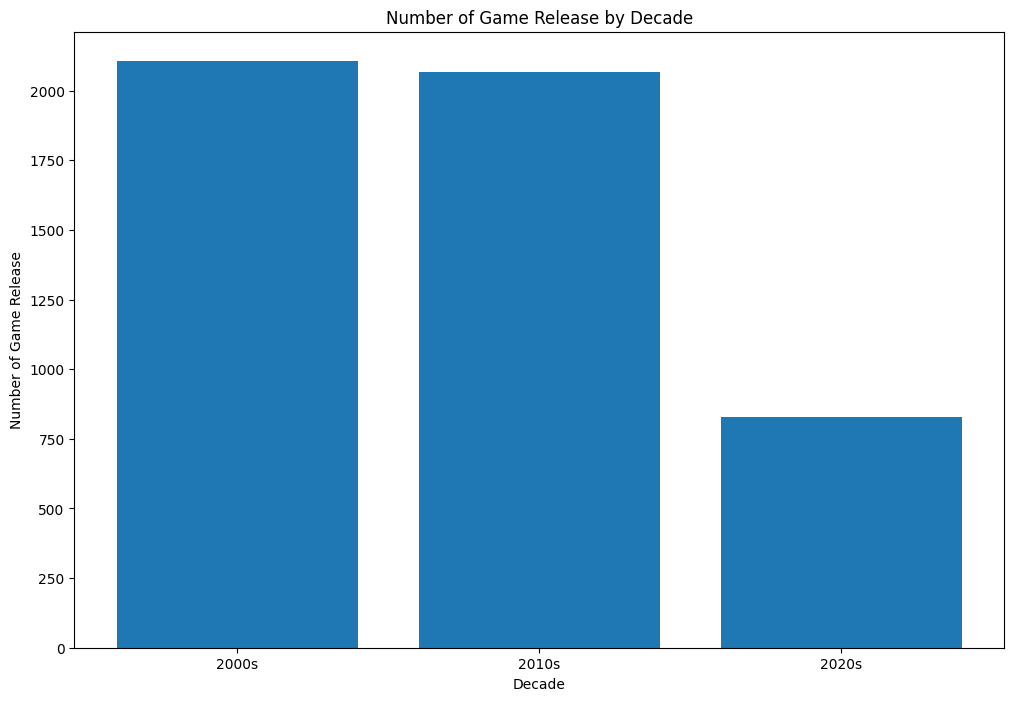

In [ ]:
#Visualize number of release
plt.figure(figsize=(12,8))
plt.bar(
    decade_analysis['Decade'].astype(str),
    decade_analysis['Game_Release']
)
plt.title("Number of Game Release by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Game Release")
plt.show()

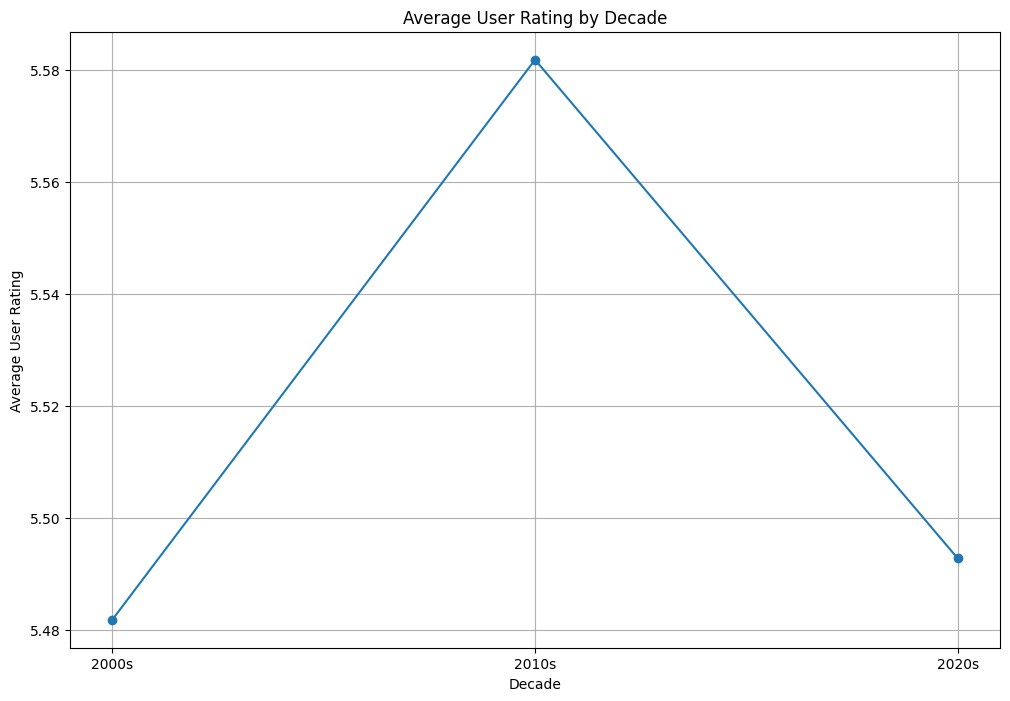

In [ ]:
#Visualize average Ratings
plt.figure(figsize=(12,8))
plt.plot(
    decade_analysis['Decade'].astype(str),
    decade_analysis['Average_Rating'],
    marker='o'
)
plt.title("Average User Rating by Decade")
plt.xlabel("Decade")
plt.ylabel("Average User Rating")
plt.grid(True)
plt.show()

In [ ]:
#Hypothesis Test
#more then two platforms : so use one-way anova test
#Check Average Ratings
platform_summary = (
    df.groupby('Platform')['User Rating']
    .agg(['count','mean','std'])
    .sort_values('mean',ascending=False)
)

print(platform_summary)

                 count      mean       std
Platform                                  
PC                1056  5.599444  2.570231
Xbox              1009  5.531032  2.585780
PlayStation        960  5.523658  2.599411
Nintendo Switch    989  5.523076  2.638923
Mobile             986  5.441895  2.602282


In [ ]:
#Perform One-Way ANOVA
from scipy import stats

platform_groups = [
    group['User Rating'].dropna()
    for platform, group in df.groupby('Platform')
]

f_statistic, p_value = stats.f_oneway(*platform_groups)

print("F-statistic:", f_statistic)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference in average user ratings between at least two platforms.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in average user ratings between the platforms.")

F-statistic: 0.47019436417637606
P-value: 0.7576711463871735
Fail to reject the null hypothesis. There is no significant difference in average user ratings between the platforms.


In [ ]:
#Correlation Analysis
correlation = df['Release Year'].corr(
    df['User Rating'],
    method='pearson'
)
print("Correlation:",correlation)

Correlation: 0.0001772553362909826


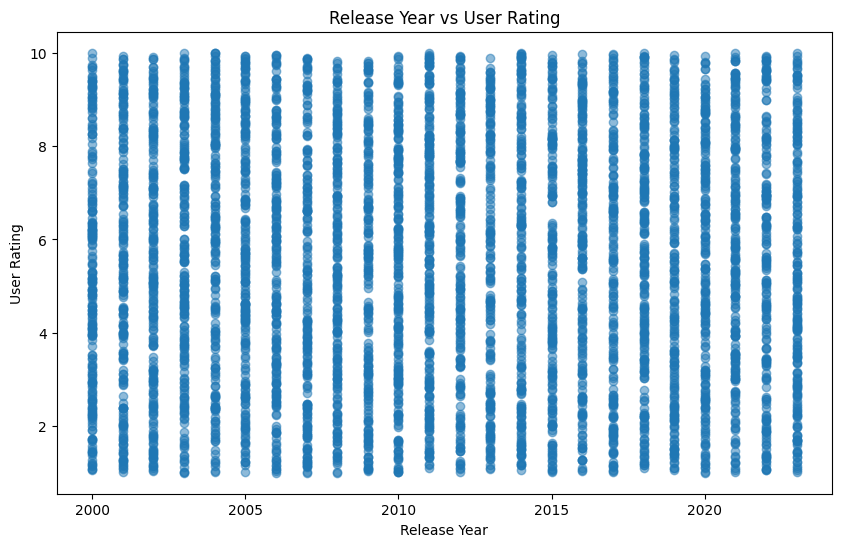

In [ ]:
#Visualize the Correlation
plt.figure(figsize=(10,6))

plt.scatter(
    df['Release Year'],
    df['User Rating'],
    alpha=0.5
)

plt.title("Release Year vs User Rating")
plt.xlabel("Release Year")
plt.ylabel("User Rating")
plt.show()

In [ ]:
#Calculate Correlation Matrix
correlation_matrix = df[
    ['Release Year', 'User Rating']
].corr()

print(correlation_matrix)

              Release Year  User Rating
Release Year      1.000000     0.000177
User Rating       0.000177     1.000000


In [ ]:
#Features
x = df[['Genre','Platform','Release Year']]

y = df['User Rating']

print(x.head())
print(y.head())

        Genre         Platform  Release Year
0      Sports  Nintendo Switch        2014.0
1      Puzzle  Nintendo Switch        2000.0
2    Strategy  Nintendo Switch        2007.0
3     Stealth      PlayStation        2005.0
4  Simulation               PC        2021.0
0    9.654719
1    3.457386
2    5.367622
3    1.240325
4    3.535476
Name: User Rating, dtype: float64
